# Part 0. Mining concepts in binary data

**The tool**: Caspailleur [pypi](https://pypi.org/project/caspailleur/) [github](https://github.com/smartFCA/caspailleur)

The name means Characteristic-Attribute-Sets-Miner with analogy to Orpailleur which is French for Gold-Miner. Orpailleur was also the name of Loria team where a lot of research on FCA and Pattern Structures had happened.

The section is based on the README.md of the package that can be found on GitHub.

In [1]:
!pip install caspailleur

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.0/60.0 kB 1.4 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 79.9/79.9 kB 6.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 340.3/340.3 kB 14.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 118.8/118.8 kB 9.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 2.1/2.1 MB 42.7 MB/s eta 0:00:00
  Created wheel for wget: filename=wget-3.2-py3-none-any.whl size=9655 sha256=66305dbdbdc886ef4db535d3859fedfbfb730a92dc857fb654fc4e122b5e00ab
  Stored in directory: /root/.cache/pip/wheels/01/46/3b/e29ffbe4ebe614ff224bad40fc6a5773a67a163251585a13a9
Successfully built wget


In [ ]:
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

In [1]:
import caspailleur as csp
df, meta = csp.io.from_fca_repo('famous_animals_en')

print(meta)
df.replace({True: 'X', False: ''})

{'title': 'Famous Animals', 'source': 'Priss, U. (2006), Formal concept analysis in information science. Ann. Rev. Info. Sci. Tech., 40: 521-543. p.525', 'size': None, 'objects': 5, 'attributes': 6, 'language': 'English', 'description': 'famous animals and their characteristics'}


,cartoon,real,tortoise,dog,cat,mammal
Garfield,X,,,,X,X
Snoopy,X,,,X,,X
Socks,,X,,,X,X
Greyfriar's Bobby,,X,,X,,X
Harriet,,X,X,,,


In [2]:
concepts_df = csp.mine_concepts(df)

concepts_df

,extent,intent,new_extent,new_intent,support,delta_stability,keys,passkeys,previous_concepts,next_concepts,sub_concepts,super_concepts
concept_id,,,,,,,,,,,,
0,"{Snoopy, Socks, Harriet, Garfield, Greyfriar's...",{},{},{},5,1,[{}],[{}],"{1, 2}",{},"{1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12}",{}
1,"{Snoopy, Socks, Garfield, Greyfriar's Bobby}",{mammal},{},{mammal},4,2,[{mammal}],[{mammal}],"{3, 4, 5, 6}",{0},"{3, 4, 5, 6, 8, 9, 10, 11, 12}",{0}
2,"{Harriet, Socks, Greyfriar's Bobby}",{real},{},{real},3,1,[{real}],[{real}],"{4, 7}",{0},"{4, 7, 10, 11, 12}",{0}
3,"{Snoopy, Garfield}","{cartoon, mammal}",{},{cartoon},2,1,[{cartoon}],[{cartoon}],"{8, 9}",{1},"{8, 9, 12}","{0, 1}"
4,"{Socks, Greyfriar's Bobby}","{mammal, real}",{},{},2,1,"[{mammal, real}]","[{mammal, real}]","{10, 11}","{1, 2}","{10, 11, 12}","{0, 1, 2}"
5,"{Snoopy, Greyfriar's Bobby}","{mammal, dog}",{},{dog},2,1,[{dog}],[{dog}],"{8, 10}",{1},"{8, 10, 12}","{0, 1}"
6,"{Socks, Garfield}","{mammal, cat}",{},{cat},2,1,[{cat}],[{cat}],"{9, 11}",{1},"{9, 11, 12}","{0, 1}"
7,{Harriet},"{tortoise, real}",{Harriet},{tortoise},1,1,[{tortoise}],[{tortoise}],{12},{2},{12},"{0, 2}"
8,{Snoopy},"{cartoon, mammal, dog}",{Snoopy},{},1,1,"[{cartoon, dog}]","[{cartoon, dog}]",{12},"{3, 5}",{12},"{0, 1, 3, 5}"


In [3]:
concepts_df = csp.mine_concepts(
  df, min_support=3, min_delta_stability=1,
  to_compute=['intent', 'keys', 'support', 'delta_stability', 'sub_concepts']
)

concepts_df

,intent,keys,support,delta_stability,sub_concepts
concept_id,,,,,
0,{},[{}],5,1,"{1, 2}"
1,{mammal},[{mammal}],4,2,{}
2,{real},[{real}],3,1,{}


In [4]:
implications_df = csp.mine_implications(df)

implications_df

,premise,conclusion,conclusion_full,extent,support,delta_stability
implication_id,,,,,,
0,{cartoon},{mammal},"{cartoon, mammal}","{Snoopy, Garfield}",2,1
1,{tortoise},{real},"{tortoise, real}",{Harriet},1,1
2,{dog},{mammal},"{mammal, dog}","{Snoopy, Greyfriar's Bobby}",2,1
3,{cat},{mammal},"{mammal, cat}","{Socks, Garfield}",2,1


In [5]:
implications_df = csp.mine_implications(
  df, basis_name='Canonical', unit_base=True,
  to_compute=['premise', 'conclusion', 'extent'],
  min_support=2,
)

implications_df

,premise,conclusion,extent
implication_id,,,
0,{cat},mammal,"{Socks, Garfield}"
1,{dog},mammal,"{Snoopy, Greyfriar's Bobby}"
2,{cartoon},mammal,"{Snoopy, Garfield}"


In [6]:
descriptions_df = csp.mine_descriptions(df)

print('__n. attributes:__', df.shape[1])
print('__n. descriptions:__', len(descriptions_df))
print('__columns:__', ', '.join(descriptions_df.columns))
descriptions_df[['description', 'support', 'is_key']].head(3)

__n. attributes:__ 6
__n. descriptions:__ 64
__columns:__ description, extent, intent, support, delta_stability, is_closed, is_key, is_passkey, is_proper_premise, is_pseudo_intent


,description,support,is_key
description_id,,,
0,{},5,True
1,{cartoon},2,True
2,{real},3,True


In [7]:
concepts_df = csp.mine_concepts(df, min_support=2)

# manually define what to show in the nodes of the diagram
new_intent_labels = ('<b>' + concepts_df['new_intent'].map(sorted).map(', '.join) + '</b>').replace('<b></b>', '')
old_intent_labels = (concepts_df['intent'] - concepts_df['new_intent']).map(sorted).map(', '.join)
intent_labels = (new_intent_labels + ';' + old_intent_labels).map(lambda l: ', '.join(l.strip(';').split(';')))
extent_labels = concepts_df['extent'].map(sorted).map(', '.join)

node_labels = intent_labels + '<br><br>' + extent_labels
node_labels = [l.replace(' ', '&nbsp') for l in node_labels] # replace space with non-breakable space for better Mermaid visualisation

diagram_code = csp.io.to_mermaid_diagram(node_labels, concepts_df['previous_concepts'])
print(diagram_code)

flowchart TD
A["<br><br>Garfield,&nbspGreyfriar's&nbspBobby,&nbspHarriet,&nbspSnoopy,&nbspSocks"];
B["<b>mammal</b><br><br>Garfield,&nbspGreyfriar's&nbspBobby,&nbspSnoopy,&nbspSocks"];
C["<b>real</b><br><br>Greyfriar's&nbspBobby,&nbspHarriet,&nbspSocks"];
D["<b>cartoon</b>,&nbspmammal<br><br>Garfield,&nbspSnoopy"];
E["mammal,&nbspreal<br><br>Greyfriar's&nbspBobby,&nbspSocks"];
F["<b>dog</b>,&nbspmammal<br><br>Greyfriar's&nbspBobby,&nbspSnoopy"];
G["<b>cat</b>,&nbspmammal<br><br>Garfield,&nbspSocks"];

A --- B;
A --- C;
B --- D;
B --- E;
B --- F;
B --- G;
C --- E;


The diagram can be visualised with Mermaid tool: https://mermaid.live/

# Main part. Mining patterns in complex data

**The tool**: Paspailleur [pypi](https://pypi.org/project/paspailleur/) [github](https://github.com/smartFCA/paspailleur)

The name can be deciphered as Pattern-Structures-Pailleur or Pattern Structures Miner.

The section is based on the Titanic tutorial: https://smartfca.github.io/paspailleur/example_from_titanic.html

In [8]:
%pip install --force-reinstall paspailleur

  Using cached paspailleur-0.1.0-py3-none-any.whl (88 kB)
  Using cached bitarray-3.8.0-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (329 kB)
  Using cached deprecation-2.1.0-py2.py3-none-any.whl (11 kB)
  Using cached frozendict-2.4.7-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (120 kB)
  Using cached tqdm-4.67.3-py3-none-any.whl (78 kB)
  Using cached caspailleur-0.2.2-py3-none-any.whl (79 kB)
  Using cached pyyaml-6.0.3-cp310-cp310-manylinux2014_x86_64.manylinux_2_17_x86_64.manylinux_2_28_x86_64.whl (770 kB)
  Using cached numpy-2.2.6-cp310-cp310-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (16.8 MB)
  Using cached scikit_mine-1.0.0-py3-none-any.whl (118 kB)
  Using cached packaging-26.0-py3-none-any.whl (74 kB)
  Using cached wget-3.2.zip (10 kB)
  Preparing metadata (setup.py) ... done
  Using cached sortedcontainers-2.4.0-py2.py3-none-any.whl (29 kB)
  Using cached scipy-1.15.3-cp310-cp310-manylinux_2_17_x

In [9]:
USE_TQDM = False  # set to False when used within documentation

## Part 1. Load data

In [1]:
import pandas as pd

df_full = pd.read_csv('https://raw.githubusercontent.com/datasciencedojo/datasets/refs/heads/master/titanic.csv', index_col=0)
df_orig = df_full.copy()
print(df_full.shape)
print(df_full.columns)

(891, 11)
Index(['Survived', 'Pclass', 'Name', 'Sex', 'Age', 'SibSp', 'Parch', 'Ticket',
       'Fare', 'Cabin', 'Embarked'],
      dtype='object')


In [2]:
# change the values of the Embarked column into the full names instead of the letters
df_full['Embarked'] = df_full['Embarked'].map({'S': 'Southampton', 'C': 'Cherbourg', 'Q': 'Queenstown'})
# change the values of the Survived column into yes and no instead of 0 1
df_full['Survived'] = df_full['Survived'].map(['No', 'Yes'].__getitem__)

# the removed columns are ticket and cabin since they are not needed for the study
df = df_full.drop(columns=['Ticket', 'Cabin'])
print(df.shape)
df.head()

(891, 9)


,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Fare,Embarked
PassengerId,,,,,,,,,
1,No,3,"Braund, Mr. Owen Harris",male,22.0,1,0,7.2500,Southampton
2,Yes,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,71.2833,Cherbourg
3,Yes,3,"Heikkinen, Miss. Laina",female,26.0,0,0,7.9250,Southampton
4,Yes,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,53.1000,Southampton
5,No,3,"Allen, Mr. William Henry",male,35.0,0,0,8.0500,Southampton


In [ ]:
# %pip install typing_extensions==4.15.0

Note: you may need to restart the kernel to use updated packages.


In [3]:
import paspailleur as psp

ImportError: cannot import name 'Self' from 'typing' (/usr/lib/python3.10/typing.py)

In [16]:
# The classical way to inherit a new Pattern class
class SurvivedPattern(psp.bip.CategorySetPattern):
    # CategorySetPattern required the definition of the Universe of categories,
    # that is the set of all possible categories that can be found in the data
    Universe = ('No', 'Yes')

# A simplified way to inherit Pattern classes
SexPattern = psp.pattern_factory(psp.bip.CategorySetPattern, Universe=('female', 'male'))

# Built-in pattern can be called by their names
EmbarkedPattern = psp.pattern_factory('CategorySetPattern', Universe=('Southampton', 'Cherbourg', 'Queenstown'))

AttributeError: module 'paspailleur' has no attribute 'bip'

In [4]:
PassengerClassPattern = psp.pattern_factory(psp.bip.ClosedIntervalPattern, BoundsUniverse=(1,2,3))
AgePattern = psp.pattern_factory('ClosedIntervalPattern', BoundsUniverse=(0, 20, 40, 60, 80))
NSiblingsPattern = psp.pattern_factory('ClosedIntervalPattern', BoundsUniverse=(0, 1, 2, 8))
NParentsPattern = psp.pattern_factory('ClosedIntervalPattern', BoundsUniverse=(0, 1, 2, 6))
FarePattern = psp.pattern_factory('ClosedIntervalPattern', BoundsUniverse=(0, 30, 100, 300, 515))

AttributeError: module 'paspailleur' has no attribute 'pattern_factory'

In [35]:
NamePattern = psp.pattern_factory(psp.bip.NgramSetPattern, StopWords=set())

In [36]:
# CartesianPattern combines Patterns for each column in the data
class PassengerPattern(psp.bip.CartesianPattern):
    DimensionTypes = {
        'Survived': SurvivedPattern,
        'Sex': SexPattern,
        'Embarked': EmbarkedPattern,
        'Pclass': PassengerClassPattern,
        'Age': AgePattern,
        'SibSp': NSiblingsPattern,
        'Parch': NParentsPattern,
        'Fare': FarePattern,
        'Name': NamePattern
    }

In [37]:
for f in df.columns:
    if df[f].isna().any():
        p = PassengerPattern.DimensionTypes[f].get_min_pattern()
        df[f] = df[f].fillna(p)
        print(f"Found NaN values in dimension {f}. Replace them by pattern: {p}")

Found NaN values in dimension Age. Replace them by pattern: [-inf, inf]
Found NaN values in dimension Embarked. Replace them by pattern: {'Cherbourg', 'Queenstown', 'Southampton'}


In [40]:
%%time
ps = psp.PatternStructure(PassengerPattern)
ps.fit(df.to_dict('index'), min_atom_support=0.1, use_tqdm=USE_TQDM)
print('#objects x #atomic_patterns', ps.shape)

#objects x #atomic_patterns (891, 42)
CPU times: user 1.36 s, sys: 222 µs, total: 1.36 s
Wall time: 1.58 s


## Part 2. Mining patterns

### Mining concepts

In [41]:
%%time
concepts = ps.mine_concepts(min_delta_stability=0.01, min_support=0.1, algorithm='gSofia', use_tqdm=USE_TQDM)

CPU times: user 7.93 s, sys: 68.3 ms, total: 8 s
Wall time: 9.73 s


In [42]:
print(f"# concepts: {len(concepts):,}")
extent, intent = concepts[50]
print("Concept #50")
print(f"* objects in the concept: {list(extent)[:10]} (some of them)")
print(f"* pattern of the concept: {intent}")

# concepts: 4,868
Concept #50
* objects in the concept: [1, 2, 3, 4, 5, 7, 8, 9, 10, 11] (some of them)
* pattern of the concept: {'Age': [0.0, 60.0], 'Embarked': NOT({'Queenstown'}), 'Fare': [0.0, 300.0], 'Parch': [0.0, 6.0], 'Pclass': [1.0, 3.0], 'SibSp': [0.0, 8.0]}


### Mining implications

In [43]:
%%time
implications = ps.mine_implications(
    min_support=0.2, max_key_length=3,
    algorithm='Talky-GI',
    reduce_conclusions=True, use_tqdm=USE_TQDM
)
print(len(implications))

30
CPU times: user 132 ms, sys: 0 ns, total: 132 ms
Wall time: 143 ms


In [44]:
print("Mined Implications:")
for premise, conclusion in implications.items():
    print(premise, f'=> ({ps.measure_support(premise)} examples)', conclusion, sep='\n')
    print()

Mined Implications:
{}
=> (891 examples)
{'Fare': [0.0, 515.0], 'Parch': [0.0, 6.0], 'Pclass': [1.0, 3.0], 'SibSp': [0.0, 8.0]}

{'Embarked': NOT({'Cherbourg'})}
=> (721 examples)
{'Fare': <= 300.0}

{'Age': <= 80.0}
=> (714 examples)
{'Age': >= 0.0}

{'Age': >= 0.0}
=> (714 examples)
{'Age': <= 80.0}

{'Pclass': >= 2.0}
=> (675 examples)
{'Fare': <= 100.0}

{'Parch': <= 0.0, 'Sex': {'male'}}
=> (484 examples)
{'SibSp': <= 2.0}

{'Sex': {'male'}, 'SibSp': <= 0.0}
=> (434 examples)
{'Parch': <= 2.0}

{'Age': >= 20.0, 'Sex': {'male'}}
=> (364 examples)
{'SibSp': <= 2.0}

{'Survived': {'No'}}
=> (549 examples)
{'Fare': <= 300.0}

{'Parch': <= 0.0, 'Survived': {'No'}}
=> (445 examples)
{'SibSp': <= 2.0}

{'Age': >= 20.0, 'Survived': {'No'}}
=> (339 examples)
{'SibSp': <= 2.0}

{'Name': {'Mr.'}}
=> (517 examples)
{'Sex': {'male'}}

{'Name': {'Mr.'}, 'Parch': <= 0.0}
=> (465 examples)
{'SibSp': <= 2.0}

{'Fare': <= 30.0, 'Name': {'Mr.'}}
=> (421 examples)
{'SibSp': <= 2.0}

{'Name': {'Mr.'},

In [45]:
p = PassengerPattern({'Fare': '>= 300'})
intent = ps.intent(ps.extent(p))
intent['Embarked'], intent['Fare']

({'Cherbourg'}, [30.0, 515.0])

In [46]:
print(f'{p} is a valid atomic pattern: ', p in p.atomic_patterns)
print(f'{p} is an atomic pattern of the pattern structure: ', p in ps.atomic_patterns)
print(f'Because {p} only describes {ps.measure_support(p)} objects')
print(f' and the minimal support of atomic patterns in the pattern structure is: ',
      min([len(extent) for extent in ps.atomic_patterns.values()]))

{'Fare': >= 300.0} is a valid atomic pattern:  True
{'Fare': >= 300.0} is an atomic pattern of the pattern structure:  False
Because {'Fare': >= 300.0} only describes 3 objects
 and the minimal support of atomic patterns in the pattern structure is:  95


### Mining subgroups

In [47]:
goal_objects = set(df[df['Survived'] == "Yes"].index)
subgroups_iterator = ps.iter_subgroups(
    goal_objects=goal_objects,
    quality_measure='Precision', quality_threshold=0.65,
    max_length=2,
    use_tqdm=USE_TQDM
)

In [48]:
%%time
subgroups = list(subgroups_iterator)
print(len(subgroups))

16
CPU times: user 19.1 ms, sys: 1.01 ms, total: 20.1 ms
Wall time: 20.5 ms


In [49]:
# Order subgroups 1) by simplicity of pattern, 2) by their quality
subgroups = sorted(subgroups, key=lambda sg_data: (len(sg_data.pattern), -sg_data.quality_value))
print("Subgroups for Survived Passengers:")
for pattern, objects, quality, quality_name in subgroups:
    print(f"Pattern: {pattern}")
    print(f"{quality_name}: {quality:.2%}, Support: {len(objects)} ({ps.measure_frequency(pattern):.0%} of data)")
    print()

Subgroups for Survived Passengers:
Pattern: {'Survived': {'Yes'}}
Precision: 100.00%, Support: 342 (38% of data)

Pattern: {'Name': {'Mrs.'}}
Precision: 79.20%, Support: 125 (14% of data)

Pattern: {'Sex': {'female'}}
Precision: 74.20%, Support: 314 (35% of data)

Pattern: {'Name': {'Miss.'}}
Precision: 69.78%, Support: 182 (20% of data)

Pattern: {'Fare': 30.0}
Precision: 83.33%, Support: 6 (1% of data)

Pattern: {'Age': <= 20.0, 'Pclass': <= 2.0}
Precision: 76.79%, Support: 56 (6% of data)

Pattern: {'Parch': >= 1.0, 'Pclass': <= 2.0}
Precision: 73.79%, Support: 103 (12% of data)

Pattern: {'Embarked': NOT({'Southampton'}), 'Fare': >= 30.0}
Precision: 72.62%, Support: 84 (9% of data)

Pattern: {'Pclass': <= 2.0, 'SibSp': >= 1.0}
Precision: 67.13%, Support: 143 (16% of data)

Pattern: {'Fare': >= 30.0, 'Pclass': <= 2.0}
Precision: 66.83%, Support: 199 (22% of data)

Pattern: {'Embarked': NOT({'Southampton'}), 'Pclass': <= 2.0}
Precision: 66.36%, Support: 107 (12% of data)

Pattern: {'

# Last part.

Visualisation (for the report)

Let's define some patterns

In [54]:
patterns = [
  PassengerPattern.get_min_pattern(),
  PassengerPattern({'Name': 'Mr.', 'Age': '>= 40'}),
  PassengerPattern({'Age': '>= 30'}),
  PassengerPattern({'Age': '>= 40', 'Pclass': '<= 2'})
]

### Line diagram (or Hasse diagram) of a partially ordered set of patterns

In [62]:
node_labels = [str(p)+'<br>'+f"support: {ps.measure_support(p):.0f}" for p in patterns]
direct_subpatterns = [{patterns.index(q) for q in patterns if q > p and not any(q > r > p for r in patterns)} for p in patterns]

print(csp.io.to_mermaid_diagram(node_labels, direct_subpatterns))

flowchart TD
A["{}<br>support: 891"];
B["{'Age': >= 40.0, 'Name': {'Mr.'}}<br>support: 95"];
C["{'Age': >= 20.0}<br>support: 550"];
D["{'Age': >= 40.0, 'Pclass': <= 2.0}<br>support: 118"];

A --- C;
C --- B;
C --- D;


If we put this code to https://mermaid.live we get the following diagram:

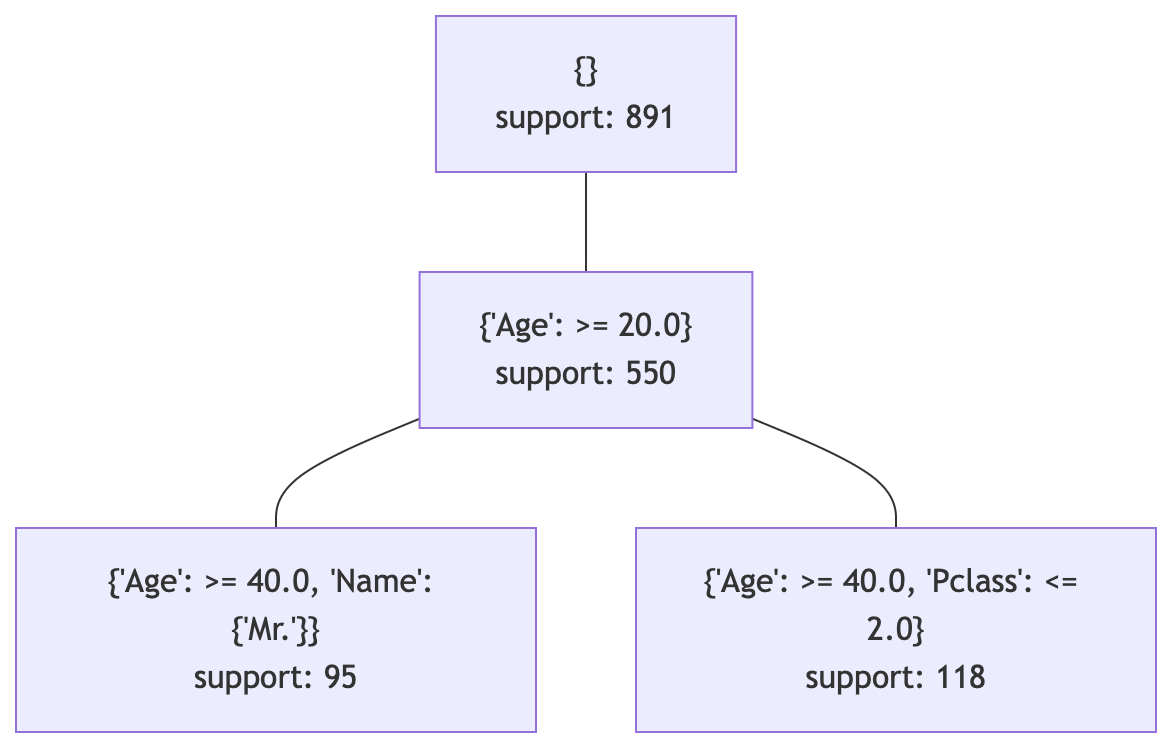

### Euler diagram

In [65]:
euler_df = dict()
for p in patterns:
  extent = ps.extent(p)
  euler_df[str(p)] = [g in extent for g in ps.objects]

euler_df = pd.DataFrame(euler_df)
euler_df

,{},"{'Age': >= 40.0, 'Name': {'Mr.'}}",{'Age': >= 20.0},"{'Age': >= 40.0, 'Pclass': <= 2.0}"
0,True,False,True,False
1,True,False,True,False
2,True,False,True,False
3,True,False,True,False
4,True,False,True,False
...,...,...,...,...
886,True,False,True,False
887,True,False,False,False
888,True,False,False,False
889,True,False,True,False


In [67]:
euler_df.astype(int).to_csv('euler_df.csv')

By uploading this csv file to https://rectvis.de/ tool you get the following diagram: every rectangle is a pattern, every number is an object (it can be a string, if you put proper row names to the dataframe).

IMPORTANT: Not all subsets of patterns can be visualised in such a way. But it often works if the number of patterns is not high.

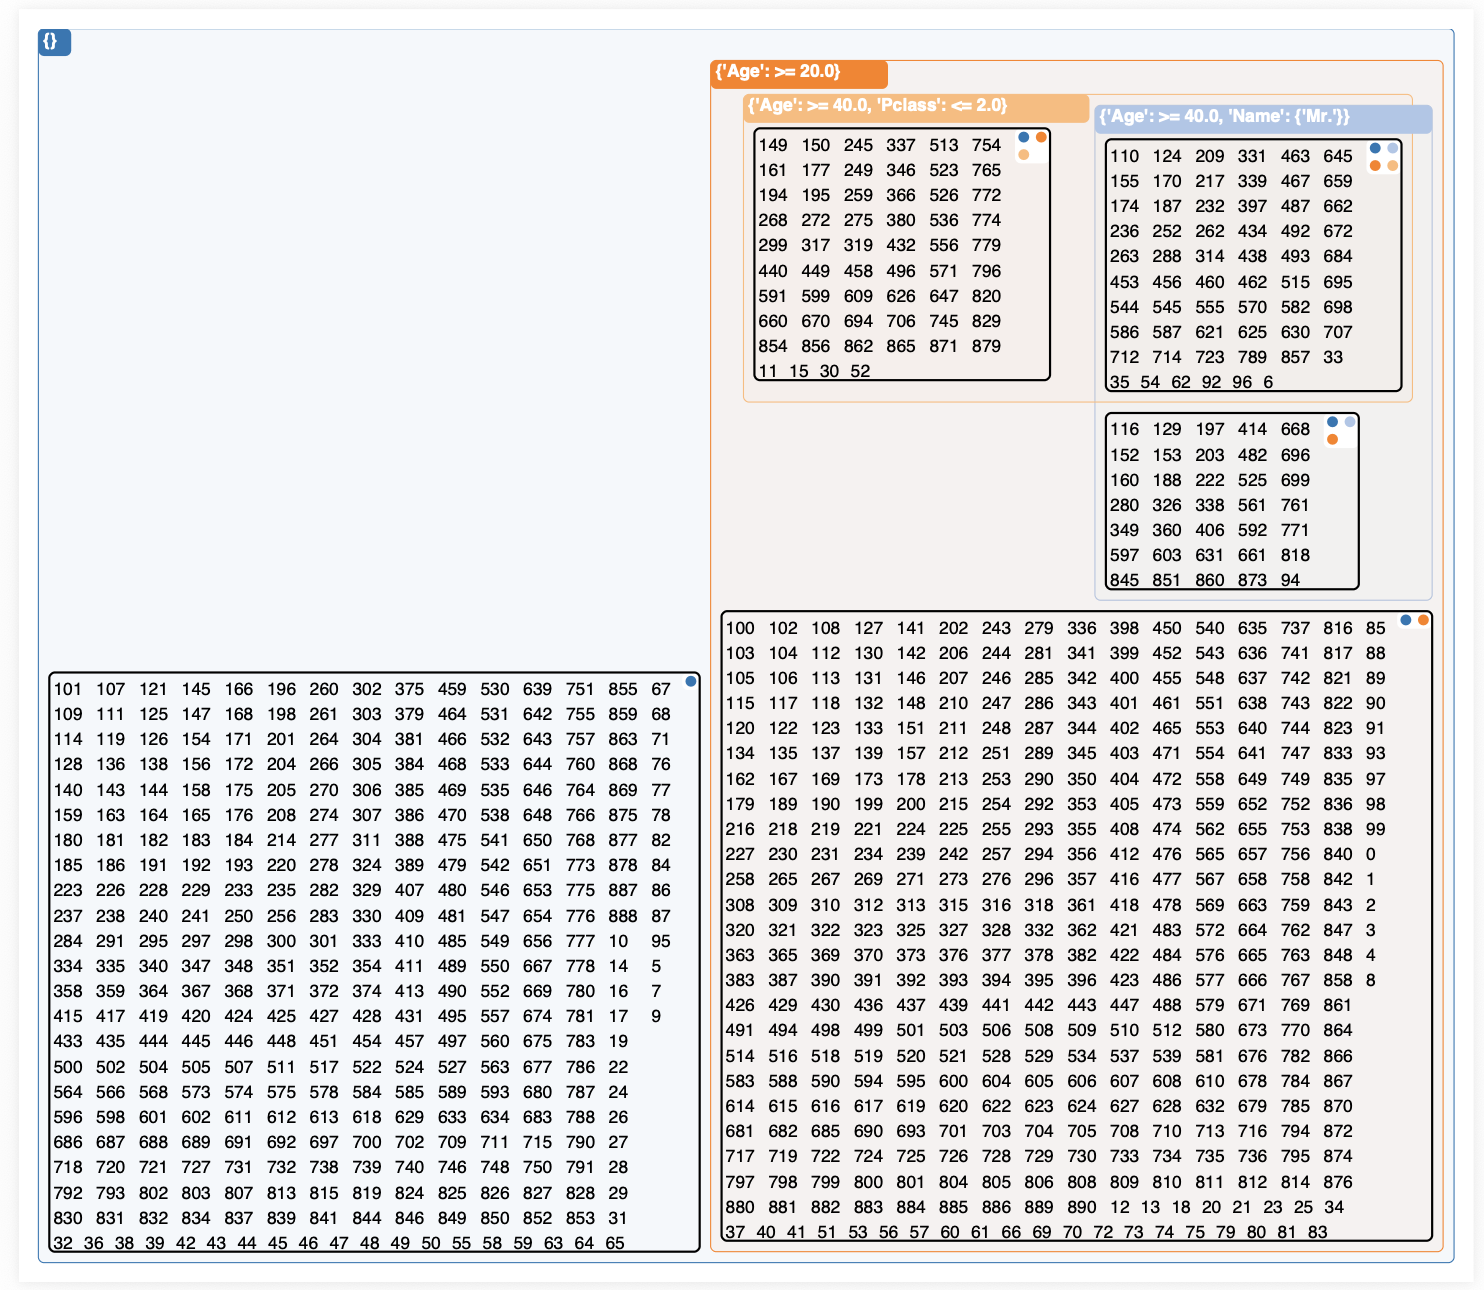

### Matplotlib visualisations

If you have some simple pattern, you can also visualise it with "by hand" with some Matplotlib functionallity.

In [106]:
p = patterns[-1]
p

{'Age': >= 40.0, 'Pclass': <= 2.0}

In [107]:
import matplotlib.pyplot as plt
import numpy as np

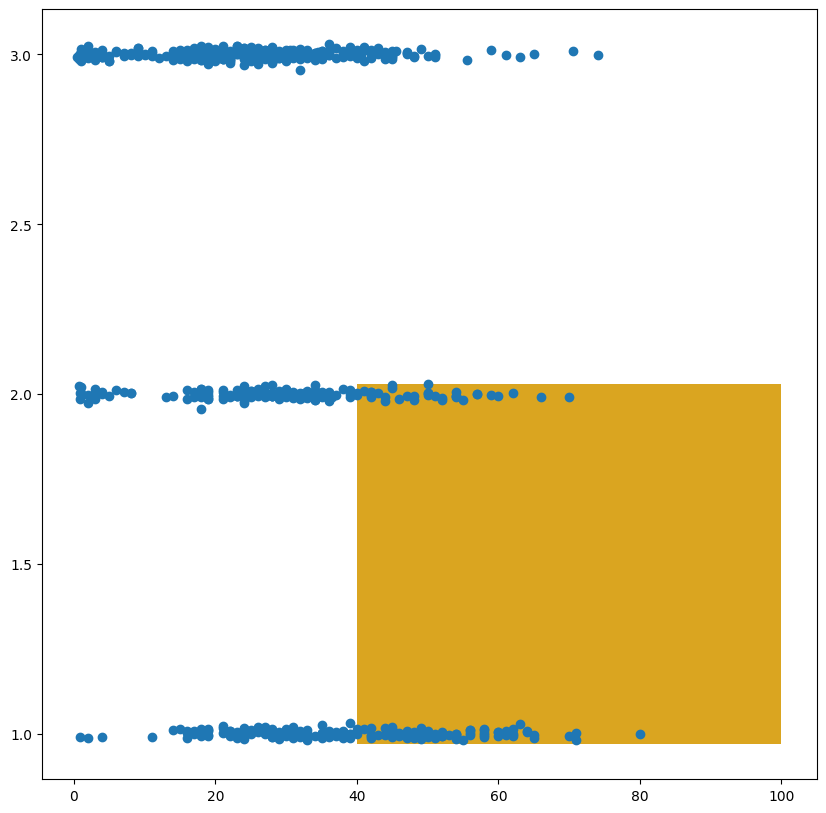

In [108]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(df_orig['Age'], df_orig['Pclass']+np.random.normal(0, 0.01, len(df_orig)), zorder=2)

patch = plt.Rectangle(xy=(40, 0.97), width=60, height=2.03-0.97, zorder=1, facecolor='goldenrod')
ax.add_patch(patch)

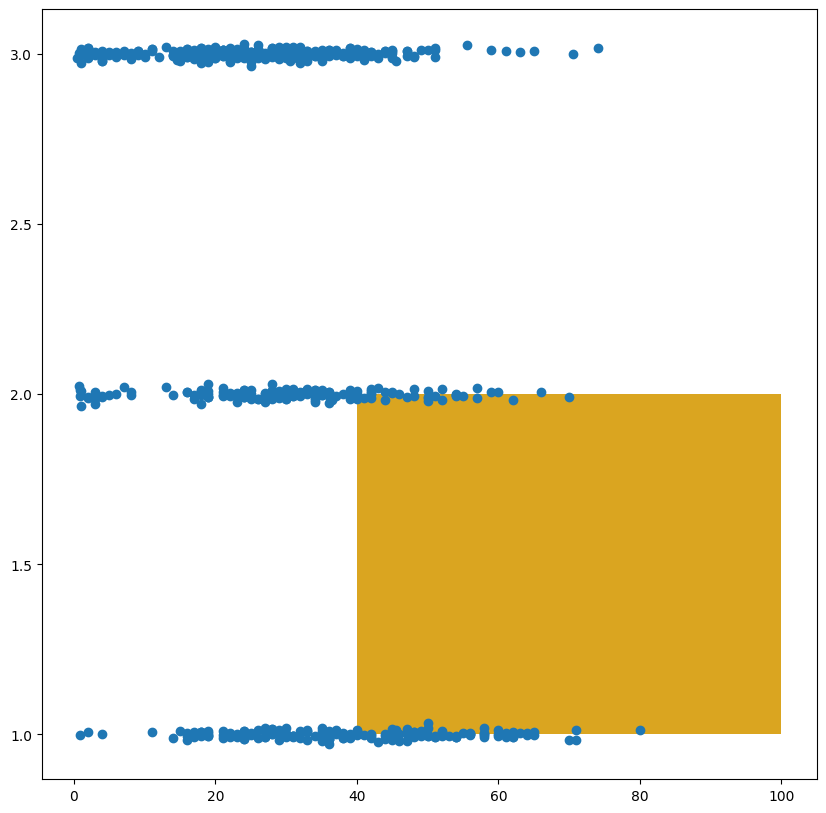

In [109]:
fig, ax = plt.subplots(figsize=(10, 10))

ax.scatter(df_orig['Age'], df_orig['Pclass']+np.random.normal(0, 0.01, len(df_orig)), zorder=2)

patch = plt.Rectangle(xy=(p['Age'].lower_bound, max(p['Pclass'].lower_bound, 1)),
                      width=60,
                      height=p['Pclass'].upper_bound-1,
                      zorder=1, facecolor='goldenrod')
ax.add_patch(patch)